# 🚢 Análisis Exploratorio de Datos (EDA) - Titanic

## Objetivo

Analizar el dataset del Titanic para identificar qué factores influyeron en la supervivencia de los pasajeros.

### Preguntas de investigación

- ¿Las mujeres y los niños tuvieron más probabilidad de sobrevivir?
- ¿La clase social influyó en la supervivencia?
- ¿Viajar acompañado de familiares aumentó las probabilidades de supervivencia?

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os
import shutil

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [104]:
os.makedirs("images", exist_ok=True)

In [105]:
path = kagglehub.dataset_download("yasserh/titanic-dataset")

print("Path to dataset files:", path)

df = pd.read_csv(os.path.join(path, 'Titanic-Dataset.csv'))

Using Colab cache for faster access to the 'titanic-dataset' dataset.
Path to dataset files: /kaggle/input/titanic-dataset


## 📊 2.1 Primera exploración del dataset

En este paso vamos a realizar una primera exploración de los datos para entender su estructura básica antes del análisis.

In [106]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2.2 Dimensiones del dataset

En esta sección vamos a ver cuántas filas (pasajeros) y columnas (variables) tiene el dataset.

In [107]:
df.shape

(891, 12)

In [108]:
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")

Filas: 891, Columnas: 12


## 2.3 Información general del dataset

Aquí analizamos tipos de datos y valores nulos para entender la calidad del dataset.

In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## 2.4 Columnas disponibles

A continuación, se listan los nombres de las variables del dataset.

In [110]:
print(df.columns.tolist())

['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


## 📊 3. Estadística Descriptiva

En este paso analizamos estadísticamente el dataset para entender la distribución de los datos numéricos y categóricos.

In [111]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [112]:
df.describe(include='object')

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Dooley, Mr. Patrick",male,347082,G6,S
freq,1,577,7,4,644


## 4. Limpieza de Datos

En este paso vamos a identificar y tratar valores faltantes y columnas irrelevantes.

In [113]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [114]:
missing_percent = (df.isnull().sum() / len(df)) * 100
print(missing_percent[missing_percent > 0])

Age         19.865320
Cabin       77.104377
Embarked     0.224467
dtype: float64


## Eliminación de columnas irrelevantes

In [115]:
df = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


## Imputación de valores faltantes

In [116]:
median_age = df['Age'].median()
df['Age'].fillna(median_age)

print(f"Edad imputada con mediana: {median_age}")
df.head()

Edad imputada con mediana: 28.0


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [117]:
mode_embarked = df['Embarked'].mode()[0]
df['Embarked'].fillna(mode_embarked)

print(f"Embarked imputado con moda: {mode_embarked}")
df.head()

Embarked imputado con moda: S


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


## 4. Limpieza final de datos

En este paso eliminamos valores faltantes restantes y verificamos que el dataset esté completamente limpio para el análisis.

In [118]:
df = df.dropna()

In [119]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


## 5. Renombrar columnas

Se renombraron algunas columnas para hacer el dataset más claro y fácil de entender.

In [120]:
df = df.rename(columns={
    'Pclass': 'Passenger_Class',
    'SibSp': 'Siblings_Spouses',
    'Parch': 'Parents_Children'
})

print(df.columns.tolist())
df.head()

['Survived', 'Passenger_Class', 'Sex', 'Age', 'Siblings_Spouses', 'Parents_Children', 'Fare', 'Embarked']


,Survived,Passenger_Class,Sex,Age,Siblings_Spouses,Parents_Children,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


## 6. Análisis univariado

Analizamos cada variable por separado para entender su distribución.

In [121]:
df['Survived'].value_counts()

,count
Survived,
0,424
1,288


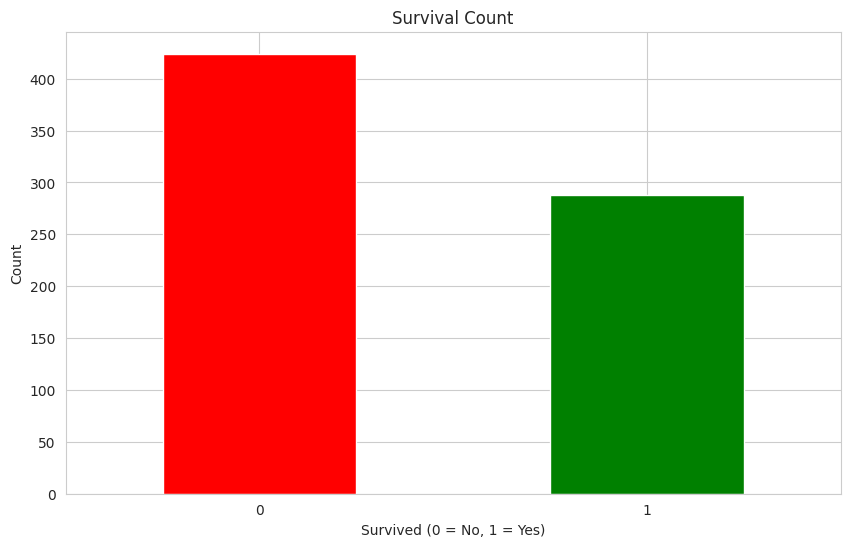

In [122]:
df['Survived'].value_counts().plot(kind='bar', color=['red', 'green'])

plt.title('Survival Count')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.savefig("images/survival_count.png")
plt.show()

In [123]:
df['Sex'].value_counts()

,count
Sex,
male,453
female,259


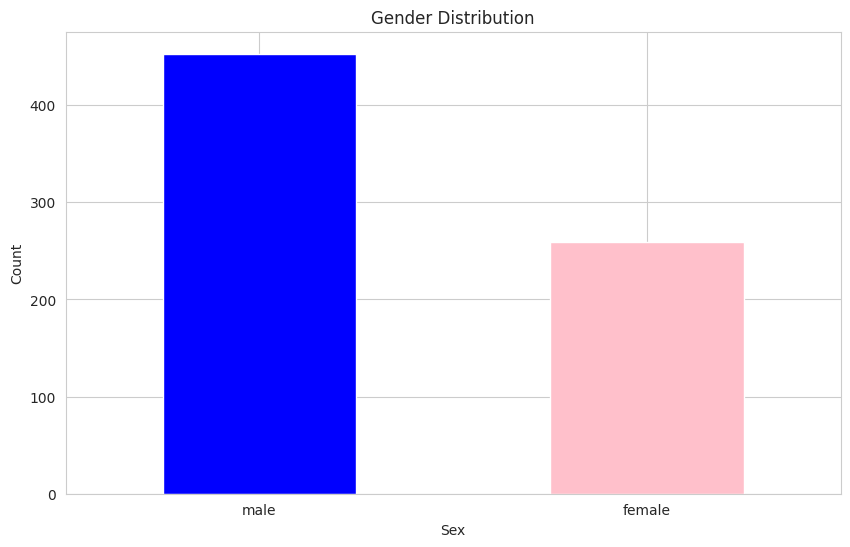

In [124]:
df['Sex'].value_counts().plot(kind='bar', color=['blue', 'pink'])

plt.title('Gender Distribution')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.savefig("images/survival_by_sex.png")
plt.show()

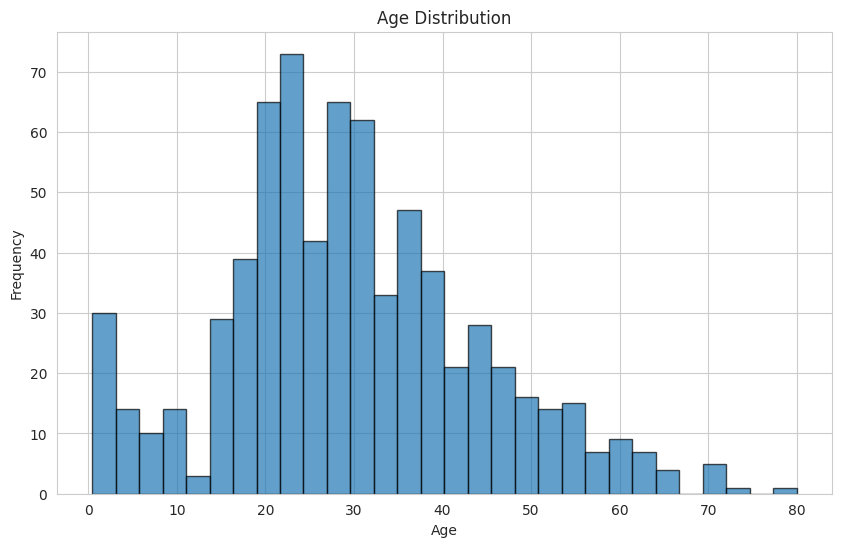

In [125]:
df['Age'].plot(kind='hist', bins=30, edgecolor='black', alpha=0.7)

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.savefig("images/age_distribution.png")
plt.show()

### 6.4 Distribución del precio de los tickets (Fare)

Se utiliza un diagrama de caja (boxplot) para analizar la distribución del precio de los billetes e identificar posibles valores atípicos (outliers).

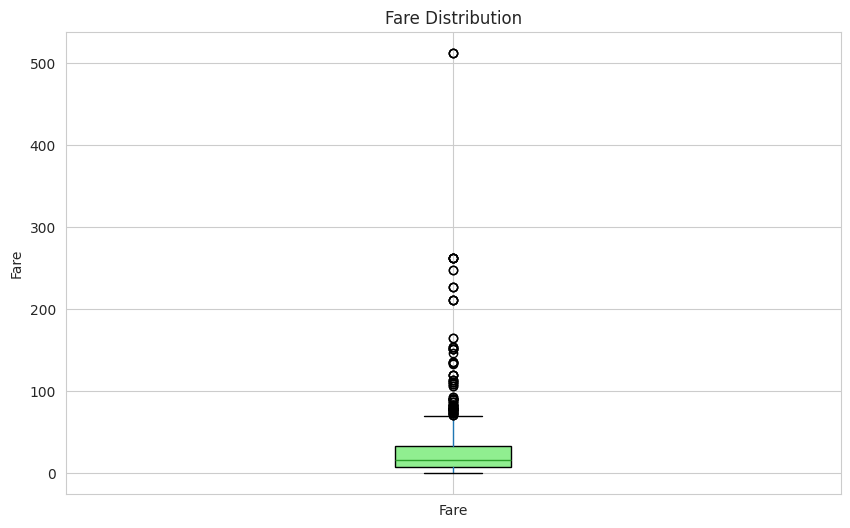

In [126]:
df.boxplot(
    column='Fare',
    patch_artist=True,
    boxprops=dict(facecolor='lightgreen')
)

plt.title('Fare Distribution')
plt.ylabel('Fare')
plt.savefig("images/fare_boxplot.png")
plt.show()

## 7.1 Relación entre sexo y supervivencia

Se analiza si el género influyó en la probabilidad de supervivencia durante el naufragio.

In [127]:
survival_by_sex = pd.crosstab(
    df['Sex'],
    df['Survived'],
    normalize='index'
) * 100

print("Porcentaje de supervivencia por sexo:")
print(survival_by_sex)

Porcentaje de supervivencia por sexo:
Survived          0          1
Sex                           
female    24.710425  75.289575
male      79.470199  20.529801


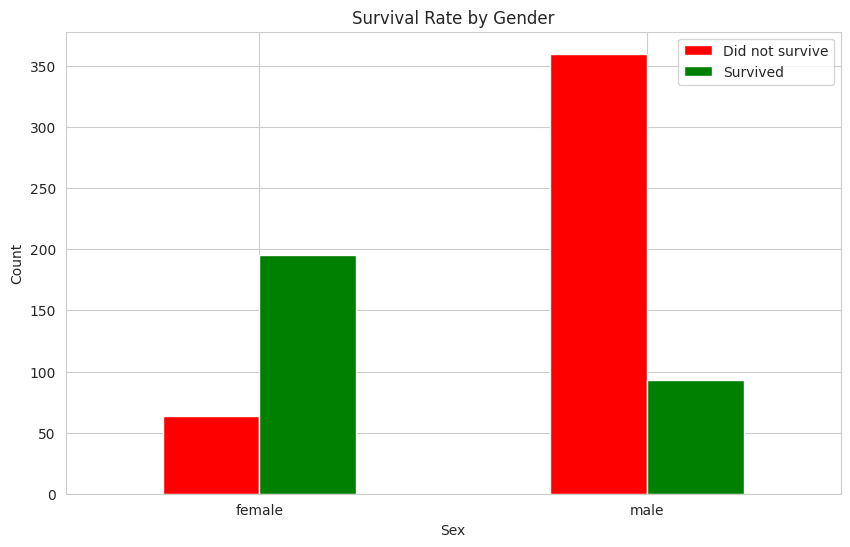

In [128]:
pd.crosstab(
    df['Sex'],
    df['Survived']
).plot(
    kind='bar',
    color=['red', 'green']
)

plt.title('Survival Rate by Gender')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.legend(['Did not survive', 'Survived'])
plt.xticks(rotation=0)
plt.savefig("images/survival_by_sex.png")
plt.show()

## 7.2 Relación entre clase del pasajero y supervivencia

Se analiza si la clase del billete influyó en las probabilidades de supervivencia.

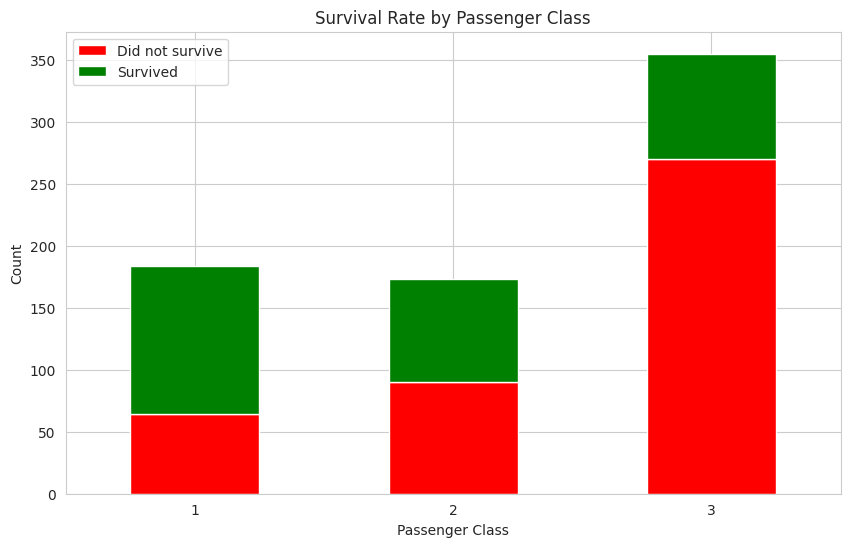

In [129]:
pd.crosstab(
    df['Passenger_Class'],
    df['Survived']
).plot(
    kind='bar',
    stacked=True,
    color=['red', 'green']
)

plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Count')
plt.legend(['Did not survive', 'Survived'])
plt.xticks(rotation=0)

plt.savefig("images/survival_by_class.png")

plt.show()

## 7.3 Relación entre edad y supervivencia

Se comparan las distribuciones de edad de los pasajeros que sobrevivieron y los que no sobrevivieron.

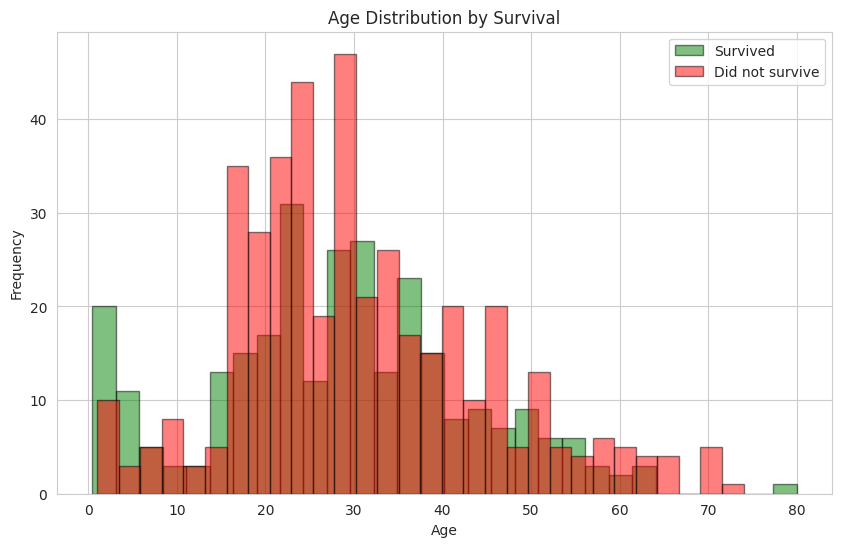

In [130]:
df[df['Survived'] == 1]['Age'].plot(
    kind='hist',
    bins=30,
    alpha=0.5,
    label='Survived',
    color='green',
    edgecolor='black'
)

df[df['Survived'] == 0]['Age'].plot(
    kind='hist',
    bins=30,
    alpha=0.5,
    label='Did not survive',
    color='red',
    edgecolor='black'
)

plt.title('Age Distribution by Survival')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.legend()

plt.savefig("images/age_survival.png")
plt.show()

## 7.4 Relación entre el precio del ticket y la supervivencia

En este análisis se compara el precio de los billetes entre los pasajeros que sobrevivieron y los que no sobrevivieron.

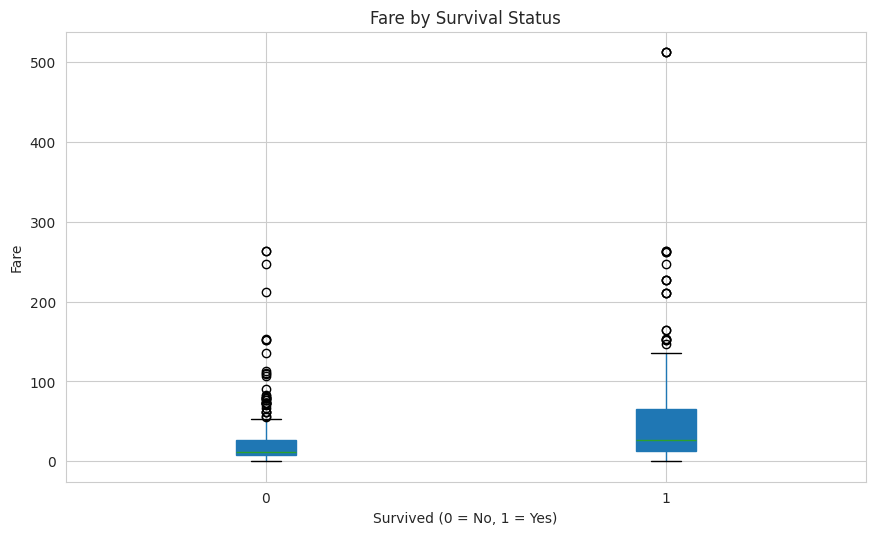

In [131]:
df.boxplot(column='Fare', by='Survived', patch_artist=True)

plt.title('Fare by Survival Status')
plt.suptitle('')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Fare')

plt.savefig("images/fare_by_survival.png")

plt.show()

# 8. Análisis Multivariado

En esta sección se estudian varias variables simultáneamente para identificar relaciones y patrones complejos dentro del dataset.

## 8.1 Matriz de correlación

Se calcula la correlación entre las variables numéricas para identificar relaciones entre ellas.

In [132]:
numeric_df = df.select_dtypes(include=[np.number])

correlation = numeric_df.corr()

print("Matriz de correlación entre variables numéricas:")
print(correlation)

Matriz de correlación entre variables numéricas:
                  Survived  Passenger_Class       Age  Siblings_Spouses  \
Survived          1.000000        -0.356462 -0.082446         -0.015523   
Passenger_Class  -0.356462         1.000000 -0.365902          0.065187   
Age              -0.082446        -0.365902  1.000000         -0.307351   
Siblings_Spouses -0.015523         0.065187 -0.307351          1.000000   
Parents_Children  0.095265         0.023666 -0.187896          0.383338   
Fare              0.266100        -0.552893  0.093143          0.139860   

                  Parents_Children      Fare  
Survived                  0.095265  0.266100  
Passenger_Class           0.023666 -0.552893  
Age                      -0.187896  0.093143  
Siblings_Spouses          0.383338  0.139860  
Parents_Children          1.000000  0.206624  
Fare                      0.206624  1.000000  


## 8.2 Visualización de correlaciones mediante Heatmap

El heatmap permite identificar visualmente qué variables están más relacionadas entre sí.

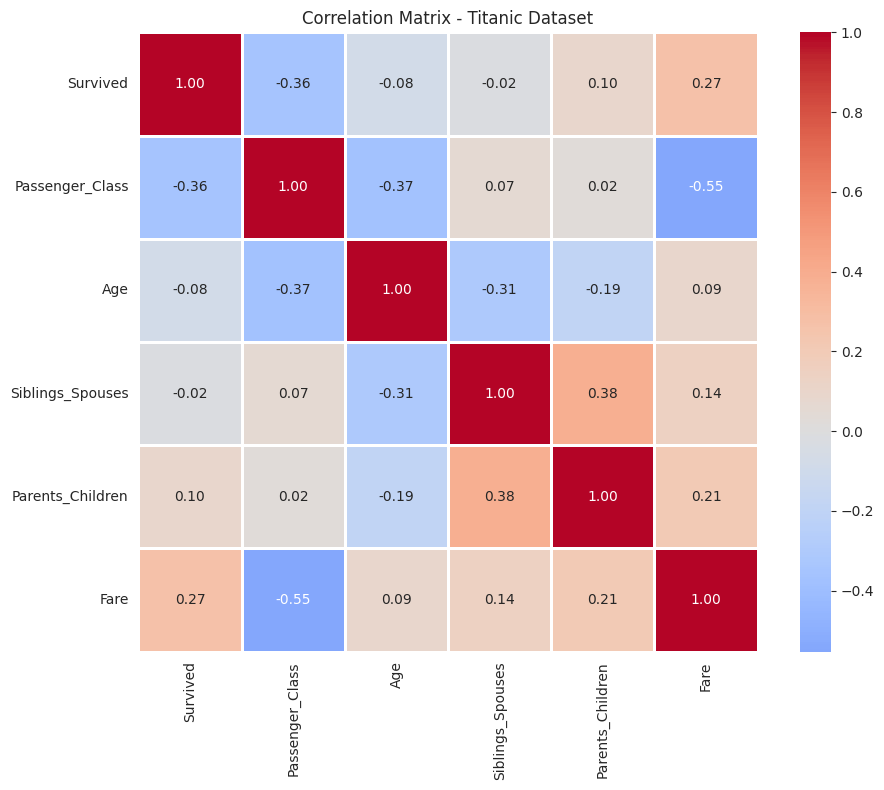

In [133]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    center=0,
    linewidths=1,
    fmt='.2f',
    square=True
)

plt.title('Correlation Matrix - Titanic Dataset')
plt.tight_layout()

plt.savefig("images/heatmap.png")
plt.show()

## 8.3 Pairplot de variables numéricas

Se visualizan simultáneamente las relaciones entre todas las variables numéricas del dataset.

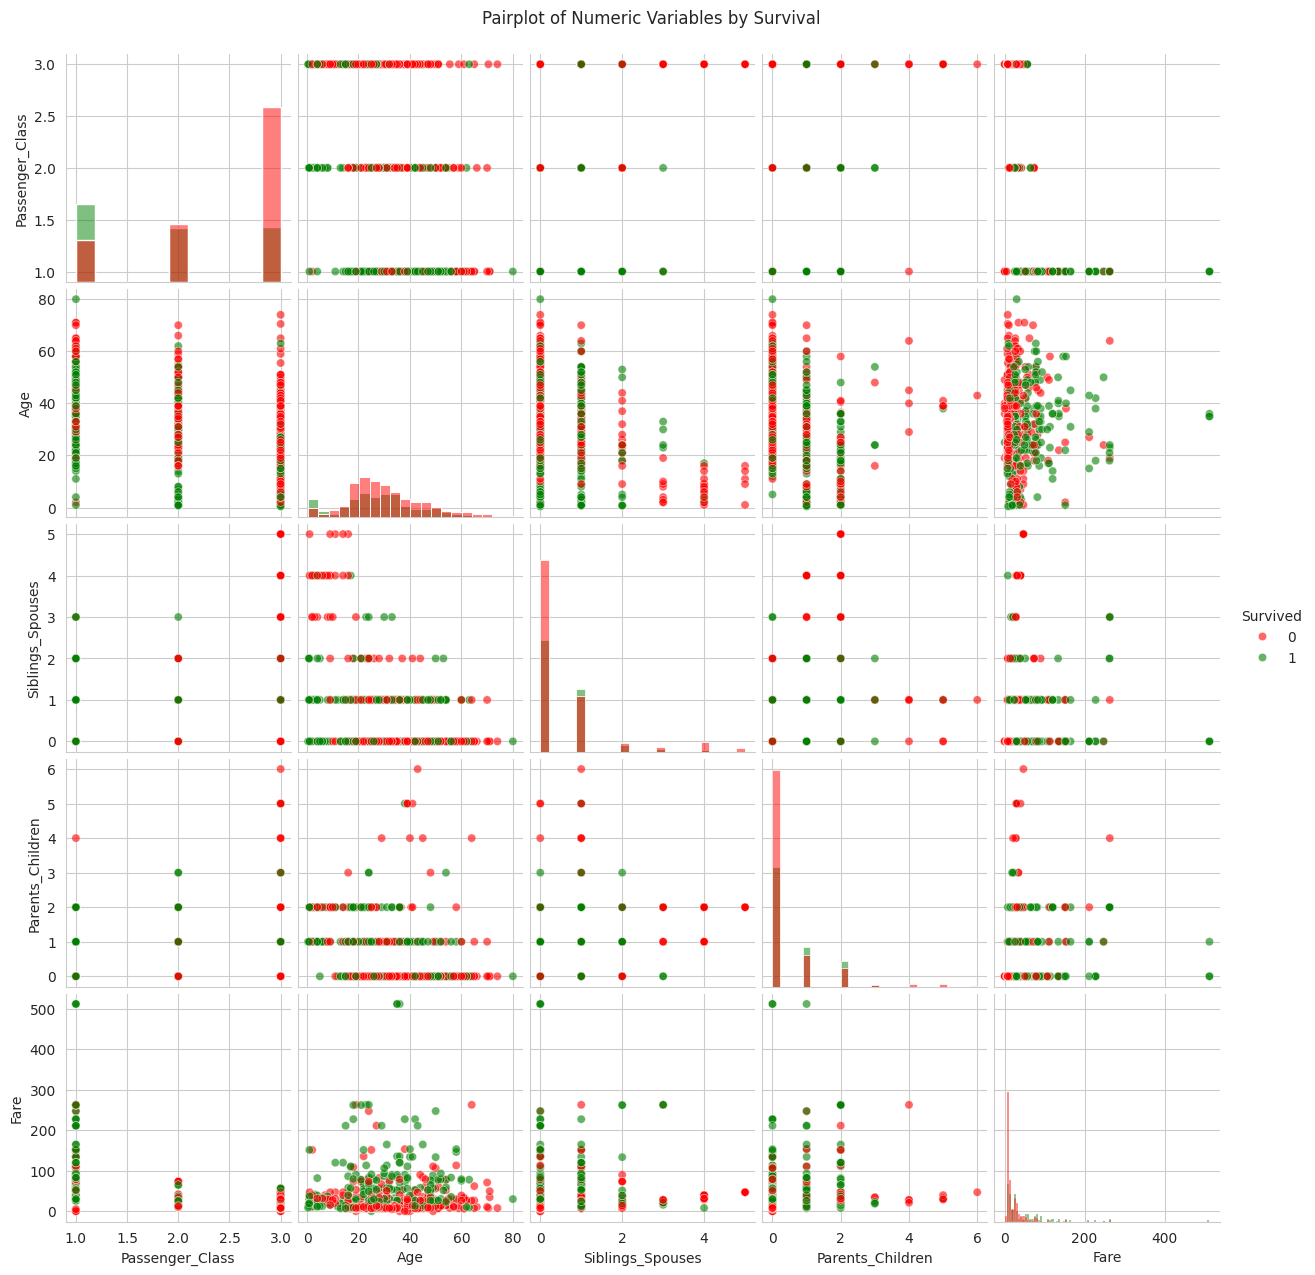

In [134]:
g = sns.pairplot(
    numeric_df,
    hue='Survived',
    palette={0: 'red', 1: 'green'},
    diag_kind='hist',
    plot_kws={'alpha': 0.6}
)

g.fig.suptitle(
    'Pairplot of Numeric Variables by Survival',
    y=1.02
)

g.savefig("images/pairplot.png")
plt.show()

## 9.1 Creación de la variable Family_Size

Se crea una nueva variable que representa el tamaño total de la familia de cada pasajero a bordo del Titanic.

In [135]:
df['Family_Size'] = (
    df['Siblings_Spouses']
    + df['Parents_Children']
    + 1
)

print("Nueva columna Family_Size creada:")
df[['Siblings_Spouses', 'Parents_Children', 'Family_Size']].head(10)

Nueva columna Family_Size creada:


,Siblings_Spouses,Parents_Children,Family_Size
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1
6,0,0,1
7,3,1,5
8,0,2,3
9,1,0,2
10,1,1,3


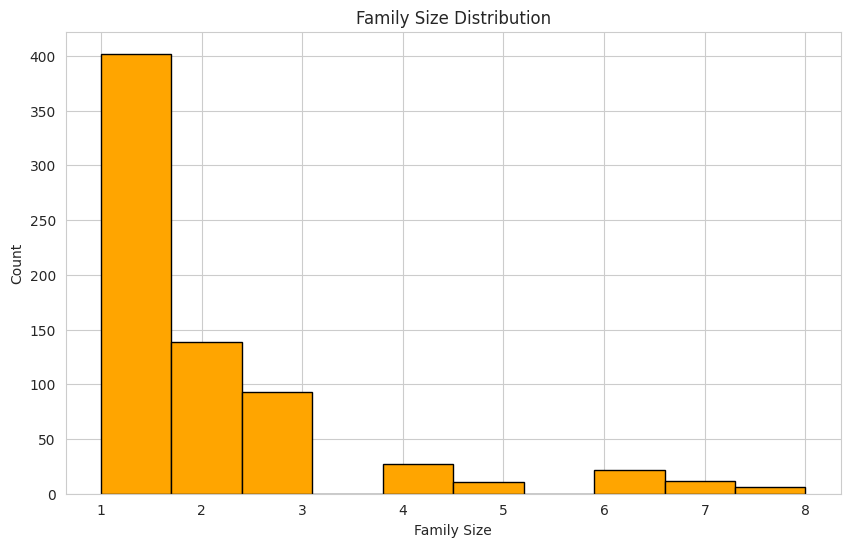

In [136]:
df['Family_Size'].plot(
    kind='hist',
    bins=10,
    edgecolor='black',
    color='orange'
)

plt.title('Family Size Distribution')
plt.xlabel('Family Size')
plt.ylabel('Count')

plt.savefig("images/family_size_distribution.png")

plt.show()

## 9.2 Creación de la variable Is_Alone

Se crea una variable binaria para identificar si el pasajero viajaba solo o acompañado.

In [137]:
df['Is_Alone'] = (
    df['Family_Size'] == 1
).astype(int)

print("Nueva columna Is_Alone creada:")
df[['Family_Size', 'Is_Alone']].head(10)

Nueva columna Is_Alone creada:


,Family_Size,Is_Alone
0,2,0
1,2,0
2,1,1
3,2,0
4,1,1
6,1,1
7,5,0
8,3,0
9,2,0
10,3,0


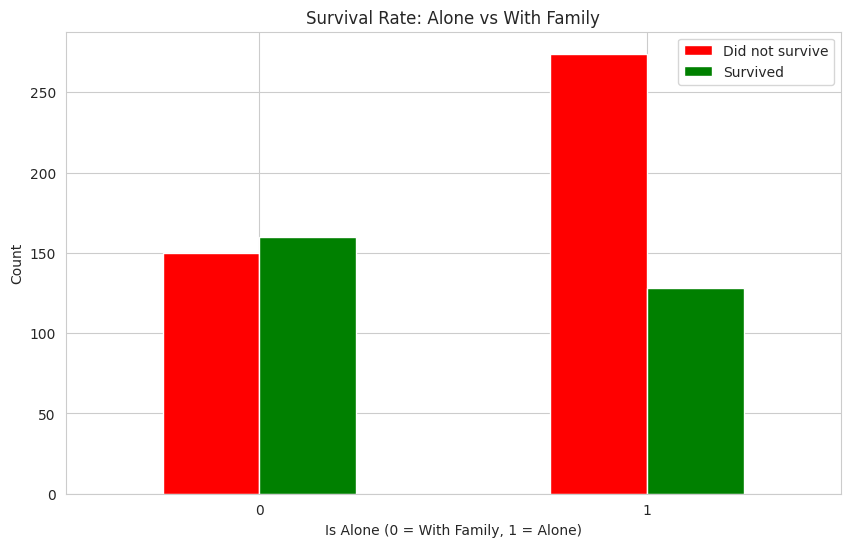

In [138]:
pd.crosstab(
    df['Is_Alone'],
    df['Survived']
).plot(
    kind='bar',
    color=['red', 'green']
)

plt.title('Survival Rate: Alone vs With Family')
plt.xlabel('Is Alone (0 = With Family, 1 = Alone)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(['Did not survive', 'Survived'])

plt.savefig("images/survival_alone_vs_family.png")

plt.show()

## 9.3 Creación de grupos de edad

La variable edad se transforma en categorías para facilitar el análisis por rangos de edad.

In [139]:
df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[0, 12, 18, 35, 60, 100],
    labels=[
        'Child',
        'Teenager',
        'Young Adult',
        'Adult',
        'Senior'
    ]
)

print("Nueva columna Age_Group creada:")
df[['Age', 'Age_Group']].head(15)

Nueva columna Age_Group creada:


,Age,Age_Group
0,22.0,Young Adult
1,38.0,Adult
2,26.0,Young Adult
3,35.0,Young Adult
4,35.0,Young Adult
6,54.0,Adult
7,2.0,Child
8,27.0,Young Adult
9,14.0,Teenager
10,4.0,Child


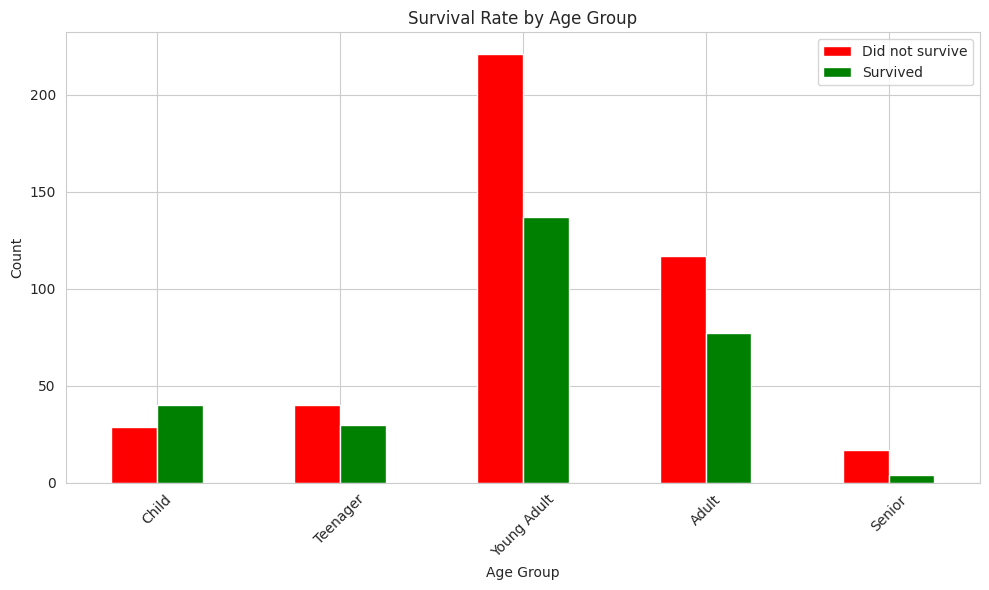

In [140]:
pd.crosstab(
    df['Age_Group'],
    df['Survived']
).plot(
    kind='bar',
    color=['red', 'green']
)

plt.title('Survival Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(['Did not survive', 'Survived'])

plt.tight_layout()

plt.savefig("images/survival_by_age_group.png")

plt.show()

# 10. Conclusiones del análisis

Finalmente se calculan algunos indicadores clave para resumir los hallazgos obtenidos durante el análisis exploratorio de datos.

In [141]:
print("=== CONCLUSIONES DEL ANÁLISIS ===\n")

survival_rate = (
    df['Survived'].sum()
    / len(df)
) * 100

print(f"1. Tasa de supervivencia general: {survival_rate:.2f}%\n")

survival_by_sex = (
    df.groupby('Sex')['Survived']
    .mean() * 100
)

print("2. Tasa de supervivencia por sexo:")
print(survival_by_sex)
print()

survival_by_class = (
    df.groupby('Passenger_Class')['Survived']
    .mean() * 100
)

print("3. Tasa de supervivencia por clase:")
print(survival_by_class)
print()

avg_age = df.groupby('Survived')['Age'].mean()

print("4. Edad promedio:")
print(f"   No sobrevivientes: {avg_age[0]:.2f} años")
print(f"   Sobrevivientes: {avg_age[1]:.2f} años")

=== CONCLUSIONES DEL ANÁLISIS ===

1. Tasa de supervivencia general: 40.45%

2. Tasa de supervivencia por sexo:
Sex
female    75.289575
male      20.529801
Name: Survived, dtype: float64

3. Tasa de supervivencia por clase:
Passenger_Class
1    65.217391
2    47.976879
3    23.943662
Name: Survived, dtype: float64

4. Edad promedio:
   No sobrevivientes: 30.63 años
   Sobrevivientes: 28.19 años


In [142]:
print("=== CONCLUSIONES DEL ANÁLISIS ===\n")

survival_rate = (
    df['Survived'].sum()
    / len(df)
) * 100

print(f"1. Tasa de supervivencia general: {survival_rate:.2f}%\n")

survival_by_sex = (
    df.groupby('Sex')['Survived']
    .mean() * 100
)

print("2. Tasa de supervivencia por sexo:")
print(survival_by_sex)
print()

survival_by_class = (
    df.groupby('Passenger_Class')['Survived']
    .mean() * 100
)

print("3. Tasa de supervivencia por clase:")
print(survival_by_class)
print()

avg_age = df.groupby('Survived')['Age'].mean()

print("4. Edad promedio:")
print(f"   No sobrevivientes: {avg_age[0]:.2f} años")
print(f"   Sobrevivientes: {avg_age[1]:.2f} años")

=== CONCLUSIONES DEL ANÁLISIS ===

1. Tasa de supervivencia general: 40.45%

2. Tasa de supervivencia por sexo:
Sex
female    75.289575
male      20.529801
Name: Survived, dtype: float64

3. Tasa de supervivencia por clase:
Passenger_Class
1    65.217391
2    47.976879
3    23.943662
Name: Survived, dtype: float64

4. Edad promedio:
   No sobrevivientes: 30.63 años
   Sobrevivientes: 28.19 años


# Conclusiones finales

- Las mujeres presentaron una tasa de supervivencia significativamente superior a la de los hombres.
- Los pasajeros de primera clase tuvieron mayores probabilidades de supervivencia.
- El precio del billete parece estar relacionado con una mayor supervivencia.
- Los niños mostraron una mayor probabilidad de sobrevivir que otros grupos de edad.
- Viajar acompañado pudo influir positivamente en las posibilidades de supervivencia.

In [143]:
import shutil
shutil.make_archive("images", 'zip', "images")

'/content/images.zip'